# Generate data from rate model

firing rates, LFP, behavior

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d

import sys

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld

import pickle as pk

2025-10-12 18:46:55.918583: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-12 18:46:55.927149: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-12 18:46:55.936364: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-12 18:46:55.939116: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-12 18:46:55.946732: I tensorflow/core/platform/cpu_feature_guar

### check trained models

In [2]:
# jitter models trained without LFP input

xlfp_model_dir = '/home/nuttidalab/Documents/renee/jitter_models/models/xor/P_rec_0.2_Taus_4.0_25.0'

xlfp_model_list = ld.find_files_keywords(xlfp_model_dir, ['Jitter_10_10', '.mat'])
# remove directories 
xlfp_model_list = [m.split('/')[-1] for m in xlfp_model_list]
xlfp_model_list.sort()

print(xlfp_model_list)
print(len(xlfp_model_list))


['Task_xor_N_200_Jitter_10_10_2025_10_09_160044.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_160147.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_160548.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_161657.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_163726.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_163742.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_163812.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_165102.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_165551.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_170029.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_171137.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_171612.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_175257.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_200153.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_200416.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_201332.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_202707.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_202718.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_20313

In [8]:
# remove models that did not train properly

import os
for i, model_name in enumerate(xlfp_model_list):
    model_path = os.path.join(xlfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs = model_data['eval_perf_mean'][0][0]
    if perfs < 0.95:
        print(f'removing {model_name} with perf {perfs}')
        os.remove(model_path)

removing Task_xor_N_200_Jitter_10_10_2025_10_10_140425.mat with perf 0.0
removing Task_xor_N_200_Jitter_10_10_2025_10_10_140520.mat with perf 0.0


In [4]:
model_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'x0', 'r0', 'w0', 'taus_gaus0', 'w_in0', 'u', 'o', 'w', 'x', 'target', 'w_out', 'r', 'm', 'som_m', 'N', 'exc', 'inh', 'w_in', 'b_out', 'som_N', 'losses', 'taus', 'eval_perf_mean', 'eval_loss_mean', 'eval_os', 'eval_labels', 'taus_gaus', 'tr', 'activation', 'stim_on_tr', 'stim_dur_tr', 'delay_tr', 'T_tr', 'all_perfs', 'opt_scaling_factor', 'scaling_factors', 'all_perfs_new', 'opt_scaling_factor_new'])

Model: Task_xor_N_200_Jitter_10_10_2025_10_09_160044.mat, Test perf: 0.99, Train trials: 9201
Model: Task_xor_N_200_Jitter_10_10_2025_10_09_160147.mat, Test perf: 0.96, Train trials: 9501
Model: Task_xor_N_200_Jitter_10_10_2025_10_09_160548.mat, Test perf: 0.96, Train trials: 13301
Model: Task_xor_N_200_Jitter_10_10_2025_10_09_161657.mat, Test perf: 1.0, Train trials: 11101
Model: Task_xor_N_200_Jitter_10_10_2025_10_09_163726.mat, Test perf: 0.96, Train trials: 21901
Model: Task_xor_N_200_Jitter_10_10_2025_10_09_163742.mat, Test perf: 0.98, Train trials: 25201
Model: Task_xor_N_200_Jitter_10_10_2025_10_09_163812.mat, Test perf: 1.0, Train trials: 14501
Model: Task_xor_N_200_Jitter_10_10_2025_10_09_165102.mat, Test perf: 0.97, Train trials: 9001
Model: Task_xor_N_200_Jitter_10_10_2025_10_09_165551.mat, Test perf: 0.96, Train trials: 11801
Model: Task_xor_N_200_Jitter_10_10_2025_10_09_170029.mat, Test perf: 1.0, Train trials: 15501
Model: Task_xor_N_200_Jitter_10_10_2025_10_09_171137.mat

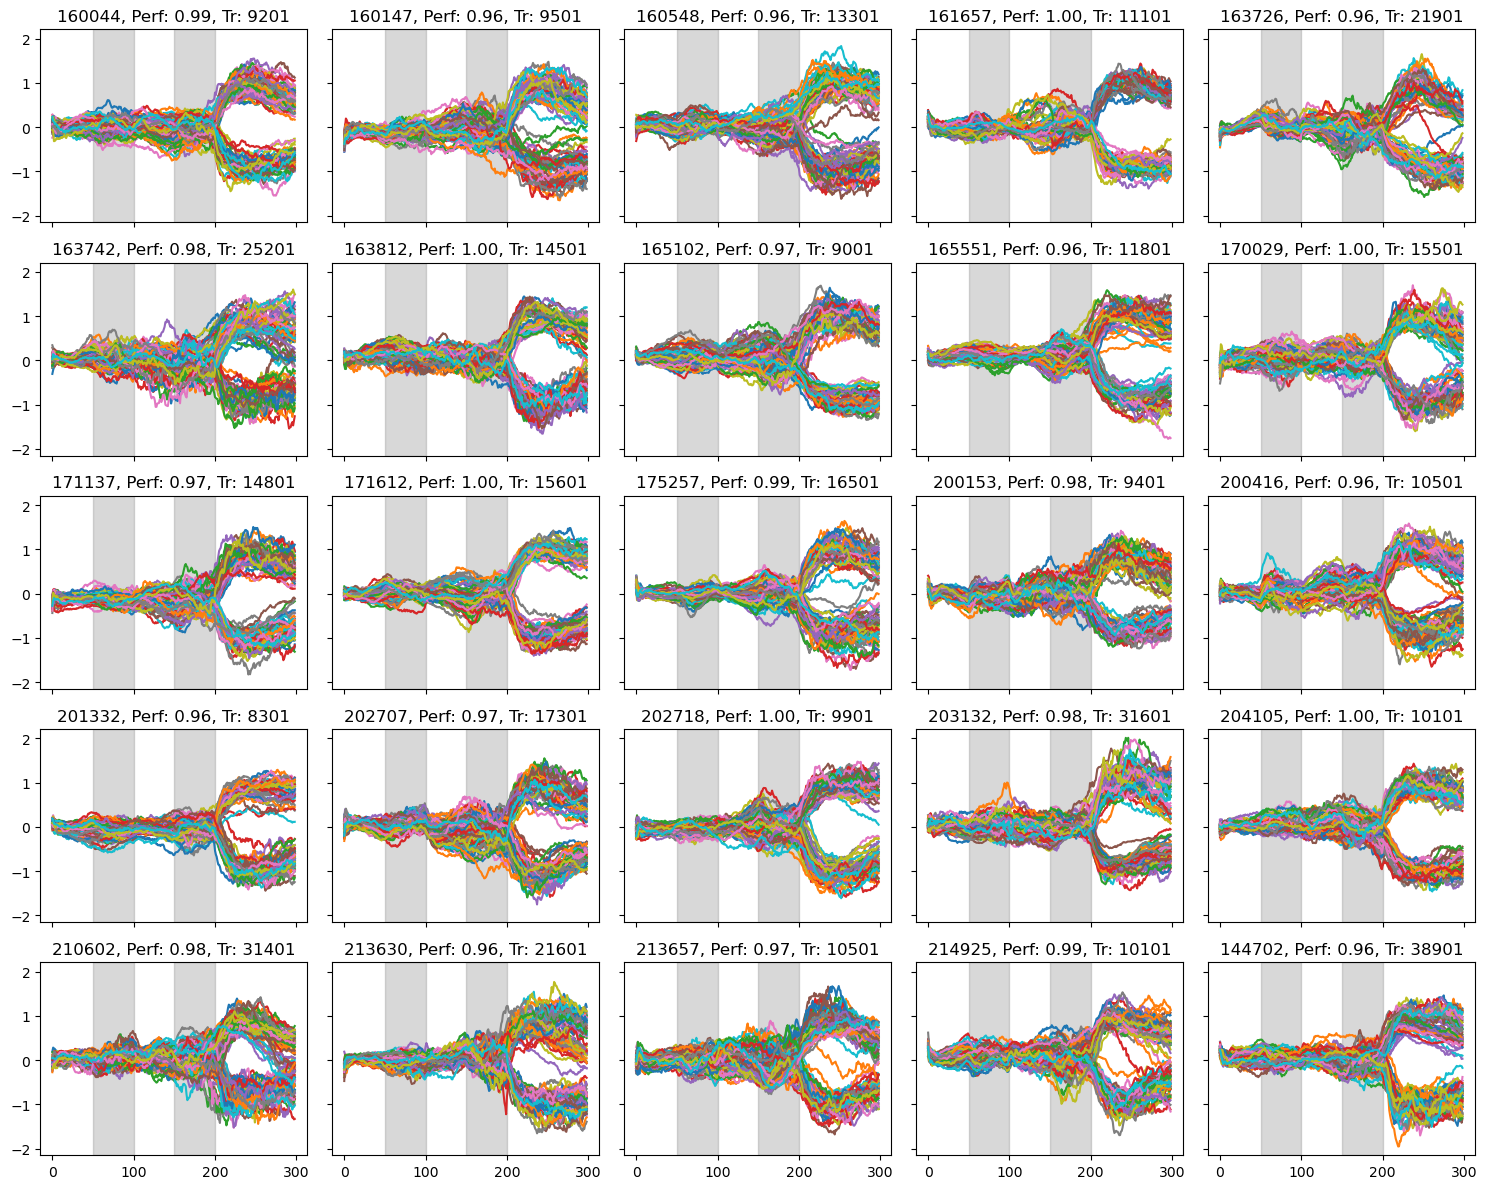

In [ ]:
fig, axs = plt.subplots(5,5, figsize=(15,12), sharex=True, sharey=True)
axs = axs.flatten()

perfs = []
train_trials = []
for i, model_name in enumerate(xlfp_model_list):
    model_path = os.path.join(xlfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perf_mean'][0][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')
    
    stim1_on = model_data['stim_on_tr'][0][0]
    stim1_off = stim1_on + model_data['stim_dur_tr'][0][0]
    stim2_on = stim1_off + model_data['delay_tr'][0][0]
    stim2_off = stim2_on + model_data['stim_dur_tr'][0][0]

    outs = model_data['eval_os']
    axs[i].plot(outs.T)
    axs[i].set_title(f'{model_name[-10:-4]}, Perf: {perfs[i]:.2f}, Tr: {train_trials[i]}')
    axs[i].axvspan(stim1_on, stim1_off, color='gray', alpha=0.3)
    axs[i].axvspan(stim2_on, stim2_off, color='gray', alpha=0.3)

plt.tight_layout()
plt.show()

### generate data for longer delay (400)

In [14]:
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
import model

Instructions for updating:
non-resource variables are not supported in the long term


In [15]:
def generate_xor_type(settings, stim1=1, stim2=-1):
     
     u = np.zeros((2, settings['T']))

     u[0, settings['stim_on']:settings['stim_on']+settings['stim_dur']] = stim1
     u[1, settings['stim_on']+settings['stim_dur']+settings['delay']:
          settings['stim_on']+2*settings['stim_dur']+settings['delay']] = stim2

     if stim1 == stim2:
          label = 'same'
     else: 
          label = 'diff'
     
     return u, label

In [17]:
n_trials = 25
eval_amp_threshold = 0.7
stim1s = [-1,1]
stim2s = [-1,1]
model_dir = xlfp_model_dir
model_list = xlfp_model_list

# delay400
settings = {
        'T': 650, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 400, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'fs': 200,
        'task': 'xor', # task name
        }

resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay'] + 10


for n_model, model_name in enumerate(model_list):
    
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    os.makedirs(output_dir, exist_ok=True)
    
    # check if saved neural_dict and bhv_dict already
    if os.path.exists(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}.pkl')) and os.path.exists(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl')):
        print(f'skipping {model_name}, already saved')
        continue

    neural_dict = {
        'r': [],
        'epsp': []
    }

    bhv_dict = {
        'perf': [],
        'trial_type': []
    }

    for stim1 in stim1s:
        for stim2 in stim2s:
            for n in range(n_trials):
                u, label = generate_xor_type(settings, stim1=stim1, stim2=stim2)
                # u = generate_LFP_input_phase(settings, u)
                trial_type = [stim1, stim2]
                # trial_type = np.unique(u, axis=1)[np.where(np.unique(u, axis=1) != 0)]

                _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', 
                                              settings=settings, u=u, calc_epsp=True)

                neural_dict['r'].append(r)
                neural_dict['epsp'].append(epsp)
                
                if label == 'same':
                    if np.max(o[resp_onset:]) > eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)
                else:
                    if np.min(o[resp_onset:]) < -eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)

                bhv_dict['trial_type'].append(trial_type)

    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    
    # save
    with open(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}.pkl'), 'wb') as f:
        pk.dump(neural_dict, f)

    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'wb') as f:
        pk.dump(bhv_dict, f)

    print(f"✔ Saved model outputs to {output_dir}")

✔ Saved model outputs to /home/nuttidalab/Documents/renee/jitter_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_2025_10_09_160044/


KeyboardInterrupt: 

In [21]:
from concurrent.futures import ProcessPoolExecutor

def run_model(model_name, settings):
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    os.makedirs(output_dir, exist_ok=True)

    # skip if already processed
    # if os.path.exists(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}.pkl')) and \
    #    os.path.exists(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl')):
    #     print(f'skipping {model_name}, already saved')
    #     return

    neural_dict = {'r': [], 'epsp': []}
    bhv_dict = {'perf': [], 'trial_type': [], 'outputs': []}

    for stim1 in stim1s:
        for stim2 in stim2s:
            for n in range(n_trials):
                u, label = generate_xor_type(settings, stim1=stim1, stim2=stim2)
                trial_type = [stim1, stim2]

                _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}',
                                              settings=settings, u=u, calc_epsp=True)

                neural_dict['r'].append(r)
                neural_dict['epsp'].append(epsp)

                if label == 'same':
                    bhv_dict['perf'].append(int(np.max(o[resp_onset:]) > eval_amp_threshold))
                else:
                    bhv_dict['perf'].append(int(np.min(o[resp_onset:]) < -eval_amp_threshold))

                bhv_dict['trial_type'].append(trial_type)
                bhv_dict['outputs'].append(o)

    # Convert lists to arrays
    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    bhv_dict['outputs'] = np.array(bhv_dict['outputs'])
    

    # Save results
    with open(os.path.join(output_dir, f'neural_dict_delay{settings["delay"]}.pkl'), 'wb') as f:
        pk.dump(neural_dict, f)

    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'wb') as f:
        pk.dump(bhv_dict, f)

    with open(os.path.join(output_dir, f'settings_dict_delay{settings["delay"]}.pkl'), 'wb') as f:
        pk.dump(settings, f)

    print(f"✔ Saved model outputs to {output_dir}")

# -- Main execution --
if __name__ == "__main__":
    with ProcessPoolExecutor() as executor:
        executor.map(run_model, model_list, [settings]*len(model_list))


✔ Saved model outputs to /home/nuttidalab/Documents/renee/jitter_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_2025_10_09_201332/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/jitter_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_2025_10_09_200153/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/jitter_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_2025_10_09_175257/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/jitter_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_2025_10_09_203132/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/jitter_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_2025_10_09_165102/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/jitter_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Jitter_10_10_2025_10_09_165551/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/jitter_models/mode

### make some quick behavior plots

In [25]:
colors = ['#6E439A', '#2B1644', '#236975', '#49BEA3']

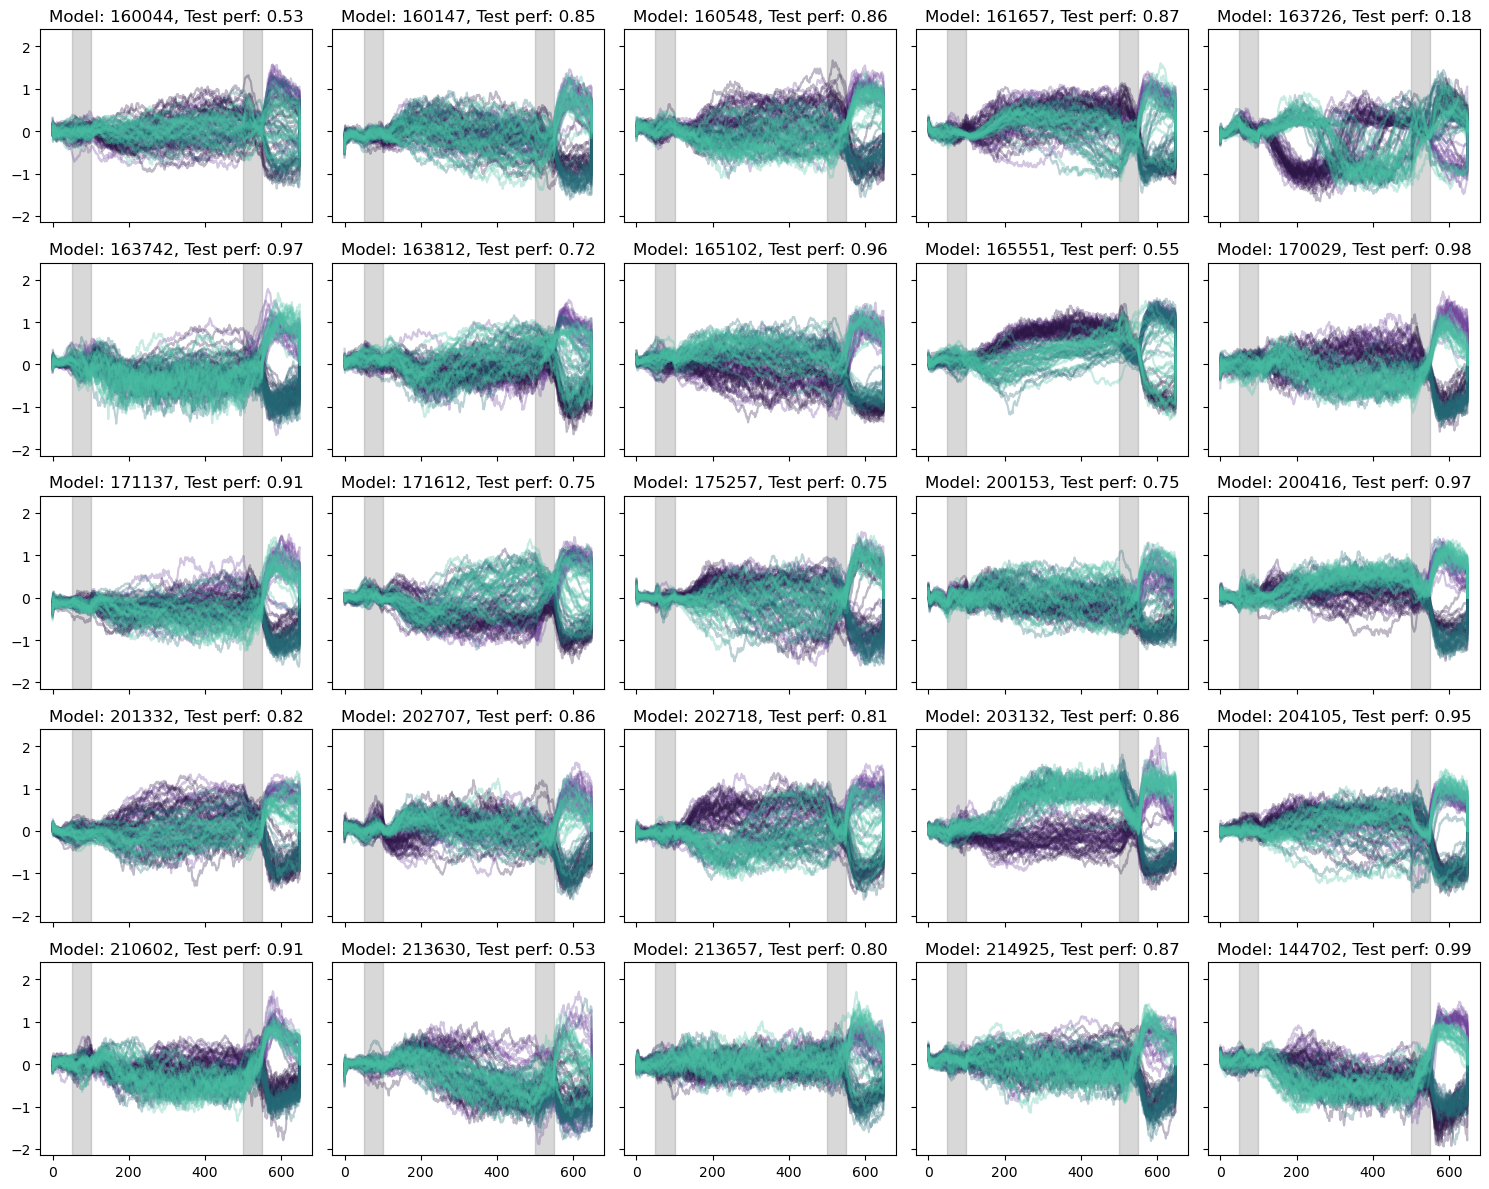

In [26]:
# plot output for each model

fig, axs = plt.subplots(5,5, figsize=(15,12), sharex=True, sharey=True)
axs = axs.flatten()
test_perfs = []
for i, model_name in enumerate(xlfp_model_list):
    output_dir = xlfp_model_dir + '/' + model_name[:-4] + '/'
    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'rb') as f:
        bhv_dict = pk.load(f)
    with open(os.path.join(output_dir, f'settings_dict_delay{settings["delay"]}.pkl'), 'rb') as f:
        settings = pk.load(f)
    
    for n in range(len(bhv_dict['outputs'])):
        axs[i].plot(bhv_dict['outputs'][n], color=colors[int(bhv_dict['trial_type'][n][0] == 1) * 2 + int(bhv_dict['trial_type'][n][1] == 1)], alpha=0.3)
    axs[i].set_title(f'Model: {model_name[-10:-4]}, Test perf: {np.mean(bhv_dict["perf"]):.2f}')
    test_perfs.append(np.mean(bhv_dict['perf']))
    stim1_on = settings['stim_on']
    stim1_off = stim1_on + settings['stim_dur']
    stim2_on = stim1_off + settings['delay']
    stim2_off = stim2_on + settings['stim_dur']
    axs[i].axvspan(stim1_on, stim1_off, color='gray', alpha=0.3)
    axs[i].axvspan(stim2_on, stim2_off, color='gray', alpha=0.3)
plt.tight_layout()
plt.show()

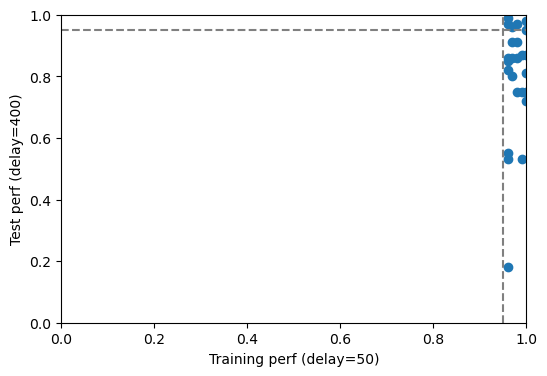

In [24]:
# plot behavior 
plt.figure(figsize=(6,4))
plt.scatter(perfs, test_perfs)
plt.axvline(x=0.95, color='gray', linestyle='--')
plt.axhline(y=0.95, color='gray', linestyle='--')
plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel('Training perf (delay=50)')
plt.ylabel('Test perf (delay=400)')
plt.show()
